<a href="https://colab.research.google.com/github/Dream-blue-wasTaken/PMPP/blob/main/greyScaleConversion/PMPP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Tue Sep 29 21:33:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8       

In [4]:
%%writefile grayscale.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>

#define CHANNELS 3

__global__ void ColorToGreyScale(unsigned char *Pout , unsigned char *Pin , int width , int height){
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  if (col < width && row< height){
    int grayOffSet = row* width + col;
    int rgbOffSet = grayOffSet* CHANNELS;
    unsigned char r = Pin[rgbOffSet ]; // red
    unsigned char g = Pin[rgbOffSet + 1 ];// green
    unsigned char b = Pin[rgbOffSet + 2 ];

    Pout[grayOffSet] = 0.21f * r + 0.71f * g + 0.07f * b;

  }
}
int main()
{
    // Image dimensions
    int width = 1024;
    int height = 1024;

    int rgbSize = width * height * CHANNELS * sizeof(unsigned char);
    int graySize = width * height * sizeof(unsigned char);

    // Host memory
    unsigned char *h_Pin =
        (unsigned char*)malloc(rgbSize);

    unsigned char *h_Pout =
        (unsigned char*)malloc(graySize);

    // Create a simple RGB test image
    // Each pixel = R, G, B
    for (int row = 0; row < height; row++) {
        for (int col = 0; col < width; col++) {

            int offset = (row * width + col) * CHANNELS;

            h_Pin[offset]     = col % 256;  // R
            h_Pin[offset + 1] = row % 256;  // G
            h_Pin[offset + 2] = 128;       // B
        }
    }

    // Device memory
    unsigned char *d_Pin;
    unsigned char *d_Pout;

    cudaMalloc((void**)&d_Pin, rgbSize);
    cudaMalloc((void**)&d_Pout, graySize);

    // Copy RGB image Host -> Device
    cudaMemcpy(d_Pin, h_Pin, rgbSize,
               cudaMemcpyHostToDevice);

    // 2D block
    dim3 blockSize(16, 16);

    // 2D grid
    dim3 gridSize(
        (width + blockSize.x - 1) / blockSize.x,
        (height + blockSize.y - 1) / blockSize.y
    );

    // Launch kernel
    ColorToGreyScale<<<gridSize, blockSize>>>(
        d_Pout,
        d_Pin,
        width,
        height
    );

    cudaDeviceSynchronize();

    // Copy grayscale image Device -> Host
    cudaMemcpy(h_Pout, d_Pout, graySize,
               cudaMemcpyDeviceToHost);

    printf("Grayscale conversion completed!\n");
    printf("Image size: %d x %d\n", width, height);
    printf("Block size: %d x %d\n",
           blockSize.x, blockSize.y);
    printf("Grid size: %d x %d\n",
           gridSize.x, gridSize.y);

    // Print a few output pixels
    printf("\nFirst 10 grayscale values:\n");

    for (int i = 0; i < 10; i++) {
        printf("%d ", h_Pout[i]);
    }

    printf("\n");

    // Free device memory
    cudaFree(d_Pin);
    cudaFree(d_Pout);

    // Free host memory
    free(h_Pin);
    free(h_Pout);

    return 0;
}

Overwriting grayscale.cu


In [5]:
!nvcc grayscale.cu -o grayscale

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [6]:
!./grayscale

Grayscale conversion completed!
Image size: 1024 x 1024
Block size: 16 x 16
Grid size: 64 x 64

First 10 grayscale values:
8 9 9 9 9 10 10 10 10 10 


COpy for image

In [7]:
!cp grayscale.cu grayscale_display.cu

In [8]:
!nvcc grayscale_display.cu -o grayscale_display
!./grayscale_display

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Grayscale conversion completed!
Image size: 1024 x 1024
Block size: 16 x 16
Grid size: 64 x 64

First 10 grayscale values:
8 9 9 9 9 10 10 10 10 10 


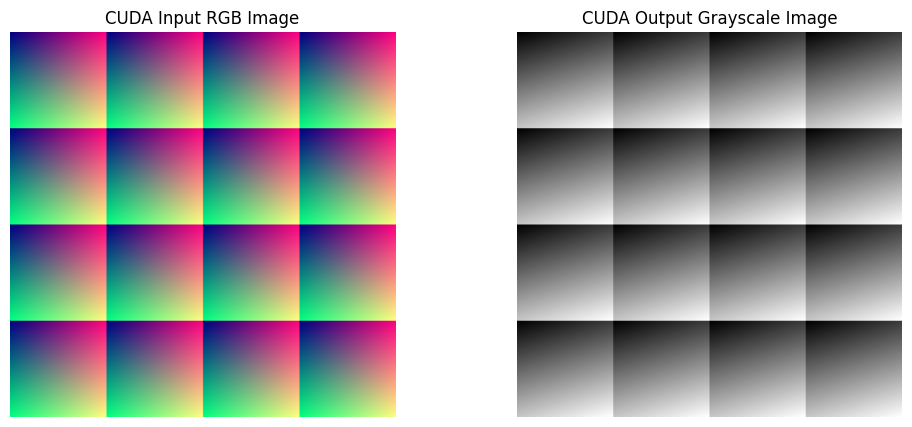

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

input_img = Image.open("input.ppm")
output_img = Image.open("output.pgm")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(input_img)
plt.title("CUDA Input RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output_img, cmap="gray")
plt.title("CUDA Output Grayscale Image")
plt.axis("off")

plt.show()